In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo
#import pyrtlib as rtl
import time

import atmo3 as a3

In [2]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)
cloud_injection_scale_in_m  = 5000.0  # Cloud-injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 128]
box_length = [22000., 22000., 11000.]

boresight  = jnp.array([box_length[0]//2., box_length[1]//2.])
passband   = {'nu': jnp.array([150.]), 'g(nu)': jnp.array([1.])}
fwhm       = 10.

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 10, 4, 17, 0, tzinfo=timezone.utc) #day with clouds

t0 = time.perf_counter()
# =============================================================================
# Scan strategy
# =============================================================================

# dt = 0 case
timesamples = [np.datetime64(time_utc)]
az          = [0.]      # in deg
el          = [45.]     # in deg

# remaining 300 samples
for sample in range(300-1):
    timesamples.append(timesamples[-1] + np.timedelta64(200, 'ms'))
    az.append(az[-1] + 0.2)
    el.append(el[-1]) 
    
t1 = time.perf_counter()

print(f"Scan setup time : {t1 - t0:.6f} s")

Scan setup time : 0.001344 s


/tmp/ipykernel_1398654/1624922884.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  timesamples = [np.datetime64(time_utc)]


In [3]:
# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for October 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

ccfile     = f'{atmo3_data}era5/2023/cc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # Cloud cover fraction
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'    # Cloud ice water content
clwcfile   = f'{atmo3_data}era5/2023/clwc.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'    # Cloud liquid water content

northwindfile = f'{atmo3_data}era5/2023/v.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # V-component North wind
eastwindfile  = f'{atmo3_data}era5/2023/u.202310.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'      # U-component East wind

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

# =============================================================================
# Initialise the atmosphere object
# ERA5 profiles are read and interpolated to the site location; profiles are
# then normalised so that the ground-level temperature and column-integrated
# PWV match the mean APEX observations recorded within ±30 min of time_utc.
# =============================================================================
atmo_box = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    cloud_cover_file_era5=ccfile,
    cloud_ice_water_content_file_era5=ciwcfile,
    cloud_liquid_water_content_file_era5=clwcfile,
    apex_datafile=apexfile
)




0.70672131147541 0.07471548950240973


In [4]:
k_array = np.arange(4*nside_grid[0]) * jnp.min(atmo_box.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

k0_cloud = 2*np.pi / cloud_injection_scale_in_m  # Cloud injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)
pofk_cloud = ( k0_cloud**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)
pofk_cloud /= np.max(pofk_cloud)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}
pspec_cloud = {'k': k_array, 'pofk': pofk_cloud}

z_scale = atmo_box.super_grid.z


atmo_box.add_ice_liquid_cloud(
        power_spec = pspec_cloud,
        seed = 42,
    ) 

atmo_box.generate_realization(time_step=0, component_name='ice water')

Random field : 24.923305 s
Apply P(k) : 5.477649 s
IRFFT : 0.035596 s
Rescaled field : 0.483592 s


In [16]:
atmo_box.generate_realization(time_step=0, component_name='liquid water')

Random field : 16.190101 s
Apply P(k) : 17.692554 s
IRFFT : 0.131105 s
Rescaled field : 0.410186 s


In [17]:
ice_cube = atmo_box.derived_cubes['ice water']
liquid_cube = atmo_box.derived_cubes['liquid water']

print(liquid_cube)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


In [6]:
cc_interp = atmo_box.super_grid.era5_interp2site(ccfile)
ciwc_interp = atmo_box.super_grid.era5_interp2site(ciwcfile)
clwc_interp = atmo_box.super_grid.era5_interp2site(clwcfile)



In [7]:
print(cc_interp)

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.00040023 0.00759292 0.0147856  0.02197829 0.02917097
 0.03636366 0.04355634 0.05074903 0.05794171 0.0651344  0.0700221
 0.06872179 0.06742149 0.06612118 0.06482

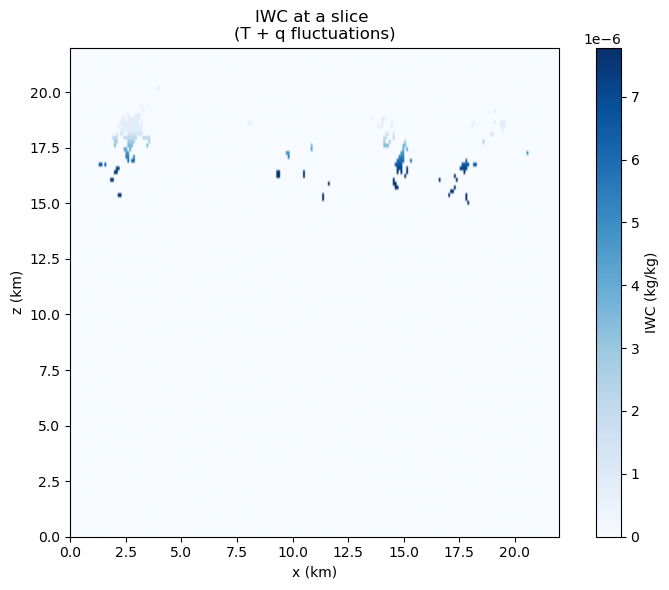

In [8]:
iwc_slice = ice_cube[:, nside_grid[1]//2, :]

plt.figure(figsize=(8,6))
plt.imshow(iwc_slice.T, origin='lower', cmap='Blues',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'IWC at a slice \n(T + q fluctuations)')
plt.colorbar(label='IWC (kg/kg)')
plt.xlabel('x (km)')
plt.ylabel('z (km)')
plt.tight_layout()
plt.show()

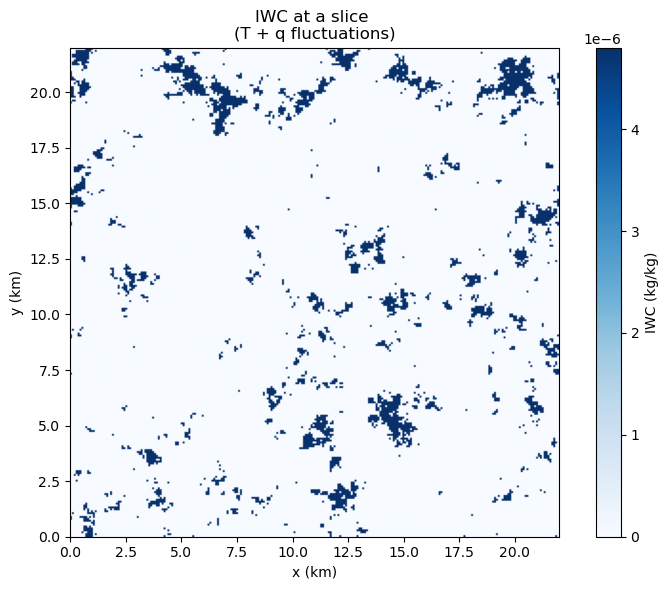

In [19]:
iwc_slice = ice_cube[:, :, 100]

plt.figure(figsize=(8,6))
plt.imshow(iwc_slice.T, origin='lower', cmap='Blues',
           extent=[0, box_length[0]/1000, 0, box_length[1]/1000])
plt.title(f'IWC at a slice \n(T + q fluctuations)')
plt.colorbar(label='IWC (kg/kg)')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.tight_layout()
plt.show()

In [ ]:
import jax.numpy as jnp
import xarray as xr
from atmo3 import atm_utils

def get_full_atmospheric_column(atmosphere, temp_era5_file, q_era5_file, dz=10.0):
    """
    Extracts the full atmospheric column from ERA5 data starting exactly at the 
    ground (site_altitude) and going up to the top of the ERA5 pressure levels.
    
    Parameters
    ----------
    atmosphere : Atmosphere
        The initialized atmo3 Atmosphere object.
    temp_era5_file : str
        Path to the ERA5 temperature NetCDF file.
    q_era5_file : str
        Path to the ERA5 specific humidity NetCDF file.
    dz : float
        The vertical resolution (in meters) for the new smoothed 1D grid.
        
    Returns
    -------
    T_full : jnp.ndarray
        Temperature profile (K).
    P_full : jnp.ndarray
        Pressure profile (Pa).
    rho_w_full : jnp.ndarray
        Water vapor density profile (kg/m^3).
    dz_full : jnp.ndarray
        Array of dz steps (m).
    """
    sg = atmosphere.super_grid
    
    # 1. Define the full vertical grid from ground to the top of ERA5
    max_era5_altitude = sg.zgeo_atsite[-1]
    z_full = jnp.arange(atmosphere.site_altitude, max_era5_altitude, dz)
    dz_full = jnp.full_like(z_full, dz)
    
    # 2. Interpolate the full pressure profile
    P_full = jnp.interp(z_full, sg.zgeo_atsite, sg.plev, left='extrapolate', right='extrapolate')
    
    # 3. Helper to extract raw full profiles from NetCDF (similar to sg.era5_interp2site)
    time_str = f'{sg.time_utc[0]:%Y-%m-%dT%H:%M:%S}'
    lat, lon = sg.site_coordinates[1], sg.site_coordinates[0] + 360.0
    
    def extract_raw_profile(filepath):
        dataset = xr.open_dataarray(filepath)
        raw_prof = jnp.asarray(dataset.sel(time=time_str).interp(latitude=lat, longitude=lon))[::-1]
        return raw_prof
    
    # 4. Extract and interpolate Temperature and Specific Humidity
    T_raw = extract_raw_profile(temp_era5_file)
    q_raw = extract_raw_profile(q_era5_file)
    
    T_full = jnp.interp(z_full, sg.zgeo_atsite, T_raw, left='extrapolate', right='extrapolate')
    q_full = jnp.interp(z_full, sg.zgeo_atsite, q_raw, left='extrapolate', right='extrapolate')
    
    # 5. Convert Specific Humidity (q) to Water Vapor Density (rho_w)
    T_v_full = atm_utils.virtual_temperature(T_full, q_full)
    rho_w_full = atm_utils.water_vapor_density(q_full, P_full, T_v_full)
    
    return T_full, P_full, rho_w_full, dz_full, z_full

# 1. Get the full continuous profile starting at the APEX telescope
T_f, P_f, rho_w_f, dz_f, z_f = get_full_atmospheric_column(
    atmo_box, 
    tempfile, 
    spechfile, 
    dz=10.0
)



# 2. Compute the cumulative zenith opacity for the whole atmosphere
tau_zenith_1D = a3.compute_tau_zenith(T_f, P_f, rho_w_f, dz_f, freqs_GHz)

# 3. tau_total_zenith is simply the very top value of this integrated column!
tau_total_zenith = tau_zenith_1D[-1, :]